# Dark matter decaying to massive decay products (`dcdm_wdm`)

**Feature report and validation** — branch `ddm-massive-decay-products`.

This notebook documents the new `dcdm_wdm` species: cold dark matter decaying to **two
identical massive daughters**, following [arXiv:2606.14849](https://arxiv.org/abs/2606.14849)
(Bencke, Lee & Kamionkowski, *"Constraints with CMB lensing on dark matter decays to massive
decay products"*). The paper's reference code (`CLASSIER-DDM`) solves an integral equation for
the daughter perturbations; CLASSpp instead evolves the **standard per-momentum-bin Boltzmann
hierarchy with a time-dependent injection source** — the ODE-native formulation (in the spirit
of Abellán, Murgia & Poulin, arXiv:2102.12498, generalized to two massive daughters).

**Validation summary** (details below; see also `scripts/validate_dcdm_wdm.py`):

| check | result |
|---|---|
| background energy conservation vs exact injection integral | $2.5\!-\!3.0\times10^{-4}$ (z = 9, 3, 0) |
| $v_{\rm kick}\to 0$ reproduces ΛCDM (same $\omega_m$) | $C_\ell^{TT}$: $9.4\times10^{-5}$, $P(k)$: $1.6\times10^{-4}$ |
| $v_{\rm kick}=1$ (massless daughters) reproduces `dcdm_dr` | $C_\ell^{TT}$: $5.5\times10^{-4}$, $P_{cb}(k)$: $3.1\times10^{-4}$ |
| $f\to 0$ reproduces ΛCDM | $C_\ell^{TT}$: $1.9\times10^{-5}$ |

The $v_{\rm kick}=1$ agreement is a strong cross-check: the massless daughters are evolved
as a 96-bin momentum hierarchy here versus the integrated dark-radiation hierarchy in
`dcdm_dr` — two entirely different discretizations of the same physics agreeing to
$3\times10^{-4}$.

## 1. The model

A cold parent $\chi$ (a fraction $f$ of the dark matter) decays with rate $\Gamma$:
$\chi \to \chi_1 + \chi_2$, two identical daughters each of mass
$m_{\chi_{1,2}} = \varepsilon\, m_\chi/2$. Each daughter is born with fixed physical momentum
$p = (m_\chi/2)\sqrt{1-\varepsilon^2}$, i.e. kick velocity
$$v_{\rm kick} = c\,\sqrt{1-\varepsilon^2},$$
and injection energy exactly $m_\chi/2$ — the parent's energy is fully transferred.
Only $(f, \Gamma, v_{\rm kick})$ matter; the parent mass drops out.

**Background.** The daughters' comoving distribution $f_0(q,\tau)$ builds up at the moving
cutoff $q_{\rm cut}(\tau) = a(\tau)\,p$: a decay at scale factor $a'$ injects daughters at
comoving momentum $q = a' p$ (paper Eqs. 4–6). CLASSpp integrates $f_i$ and
$g_i \equiv \partial f_0/\partial\ln q|_{q_i}$ per momentum bin in the background ODE, with a
normalized Gaussian kernel in $\ln q$ replacing the Dirac delta. The kernel normalization makes
the energy-injection sum rule $\dot\rho_{\rm wdm} + 3\mathcal{H}(\rho_{\rm wdm}+P_{\rm wdm})
= a\Gamma\rho_{\rm dcdm}$ **exact by construction** for any grid.

**Perturbations** (synchronous gauge). The daughters evolve *unnormalized* multipoles
$\psi_\ell(q_i) \equiv (\Delta f)_\ell$ — regular through $f_0=0$ — obeying the standard CLASS
ncdm hierarchy with $\mathrm{d}\ln f_0/\mathrm{d}\ln q \to g_i$, plus the injection source
$J_i\,\delta_{\rm dcdm}$ on $\ell=0$ (paper Eq. 8). The steep moving edge of $f_0$ lives in
$g_i$, so the metric terms reproduce the exact injection conditions in the continuum limit —
no integral equation, no evolver restarts.

**Input reference** (dot-syntax instance, `type = dcdm_wdm`):

| key | meaning | default |
|---|---|---|
| `Gamma` \| `log10Gamma` \| `lifetime` \| `log10lifetime` | decay rate (km/s/Mpc) or lifetime (yr) | required |
| `vkick` XOR `epsilon` | kick velocity $v/c$, or mass retention $\varepsilon$ | required |
| `Omega_ini` \| `omega_ini` XOR `Omega_dcdmwdm` \| `omega_dcdmwdm` | parent initial abundance (dcdm convention) or combined sector density today | required |
| `momenta_bins` | daughter momentum bins (log-spaced in $q$) | 96 |
| `q_min_ratio` | grid lower edge = this fraction of the kick momentum (grid "opens" at $a$ = this value) | 1e-4 |
| `kernel_width` | injection kernel width in bins | 1.0 |
| `l_max` | daughter hierarchy cutoff | `l_max_ncdm` |

The unstable fraction is $f = \Omega_{\rm ini}^{\rm ddm} / (\Omega_{\rm ini}^{\rm ddm} + \Omega_{\rm cdm})$,
and $\Gamma[\mathrm{km/s/Mpc}] = 977.79 / \Gamma^{-1}[\mathrm{Gyr}]$.

**Scope**: synchronous gauge only; scalar modes (the daughters do not contribute to tensor
anisotropic stress); no fluid approximation (full hierarchy always). Internally $q$ is measured
in units of $T_{\rm cmb}$ with the kick momentum fixed at $q_{\rm kick}=10$ and daughter mass
$M = q_{\rm kick}\,\varepsilon/v_{\rm kick}$ — only ratios are physical.

> **Performance note (evolver choice).** The daughter adds `momenta_bins × (l_max+1)` ≈ 1700
> equations per mode. The default stiff `ndf15` evolver spends its time on Jacobians and LU
> factorizations this system does not need: switching to `evolver = 2` (Dormand–Prince RK45)
> is **14× faster** (58.4 s → 4.1 s for a full lensed-$C_\ell$ run at `momenta_bins = 96`,
> $\ell_{\rm max}=2500$) and agrees with `ndf15` to $3.5\times10^{-5}$ in $C_\ell^{TT}$,
> $C_L^{\phi\phi}$ and $P(k)$. All runs below use `evolver = 2`.

In [1]:
import time

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from classy import Class

# House style: recessive grid/axes, thin marks, validated categorical palette
# (fixed slot order; validated with the dataviz six-check script, light surface).
C1, C2, C3, C6 = "#2a78d6", "#1baf7a", "#eda100", "#e34948"
NEUTRAL = "#52514e"
matplotlib.rcParams.update({
    "figure.figsize": (8.0, 4.5), "figure.dpi": 110,
    "lines.linewidth": 2.0,
    "axes.grid": True, "grid.color": "#e5e4e0", "grid.linewidth": 0.7,
    "axes.edgecolor": "#c9c8c4", "axes.linewidth": 0.8,
    "axes.labelcolor": "#31302e", "text.color": "#31302e",
    "xtick.color": "#52514e", "ytick.color": "#52514e",
    "axes.titlesize": 11, "axes.labelsize": 10.5,
    "legend.frameon": False, "font.size": 10,
})

GYR = 977.792  # 1 Gyr^-1 in km/s/Mpc

BASE = {
    "h": 0.6736, "omega_b": 0.02237,
    "output": "tCl,pCl,lCl,mPk", "lensing": "yes",
    "l_max_scalars": 2500, "P_k_max_h/Mpc": 1.0,
    "gauge": "synchronous", "evolver": "2",
}
OMEGA_DM = 0.26  # total early-time DM fraction (stable + unstable)


def ddm_pars(f, inv_gamma_gyr, vkick, bins=96):
    return {
        "Omega_cdm": OMEGA_DM * (1.0 - f),
        "ddm.type": "dcdm_wdm",
        "ddm.Gamma": GYR / inv_gamma_gyr,
        "ddm.vkick": vkick,
        "ddm.Omega_ini": OMEGA_DM * f,
        "ddm.momenta_bins": bins,
    }


def run(extra, background=False):
    c = Class()
    c.set({**BASE, **extra})
    t0 = time.time()
    c.compute()
    out = {"t": time.time() - t0}
    out["lensed"] = c.lensed_cl(2000)
    out["raw"] = c.raw_cl(2000)
    kk = np.logspace(-3, 0, 300)
    out["k"] = kk
    out["pk"] = np.array([c.pk(k * c.h(), 0.0) for k in kk])
    try:
        out["pk_cb"] = np.array([c.pk_cb(k * c.h(), 0.0) for k in kk])
    except Exception:
        out["pk_cb"] = out["pk"]  # no warm matter present: P_cb == P_m
    if background:
        out["bg"] = c.get_background()
        out["h"] = c.h()
        out["Omega_g"] = c.Omega_g()
        out["H0"] = c.Hubble(0)
    out["derived"] = c.get_current_derived_parameters(["ra_rec"])
    c.struct_cleanup()
    c.empty()
    return out


def bgcol(bg, name):
    for key in (name, "(.)" + name):
        if key in bg:
            return bg[key]
    raise KeyError(f"{name}; available: {sorted(bg.keys())}")


print("reference LCDM ...")
lcdm = run({"Omega_cdm": OMEGA_DM})
print(f"  {lcdm['t']:.1f} s")

reference LCDM ...
  1.1 s


## 2. Background: injection, energy conservation, and the daughter distribution

A representative model with a large unstable fraction so the daughter density is clearly
visible: $f=0.3$, $\Gamma^{-1}=3\,$Gyr, $v_{\rm kick}=0.05$.

The dashed overlay is the **exact** injection-time integral
$$\rho_{\rm wdm}(a) = \int^{\tau(a)} \mathrm{d}\tau'\; a'\Gamma\rho_{\rm dcdm}(a')
\left(\frac{a'}{a}\right)^{3} \sqrt{\varepsilon^2 + (1-\varepsilon^2)\left(\frac{a'}{a}\right)^{2}},$$
i.e. number dilution × per-particle energy redshift of daughters born with energy $m_\chi/2$.
Agreement at the few $\times 10^{-4}$ level (grid/kernel resolution) is enforced by a unit test
(`species/dcdm_wdm_test.cpp`); here we show it visually. The quoted deviation is for
$a \geq 10^{-2}$: the exact integral also counts the decays from before the grid opens at
$a = $ `q_min_ratio` $= 10^{-4}$ (a $\sim\!10^{-6}$ mass fraction, dropped by construction),
which dominate the *ratio* while the binned population is still tiny — visible as the steep
rise of the green curve onto the dashed one. The equation-of-state panel shows the daughters
cooling from $w \simeq v_{\rm kick}^2/3$ at injection toward the $w \propto a^{-2}$ free
redshift once decays complete — far below the radiation limit for physical kicks.

  4.3 s


max |rho_exact/rho_wdm - 1| for a >= 1e-2: 6.84e-04


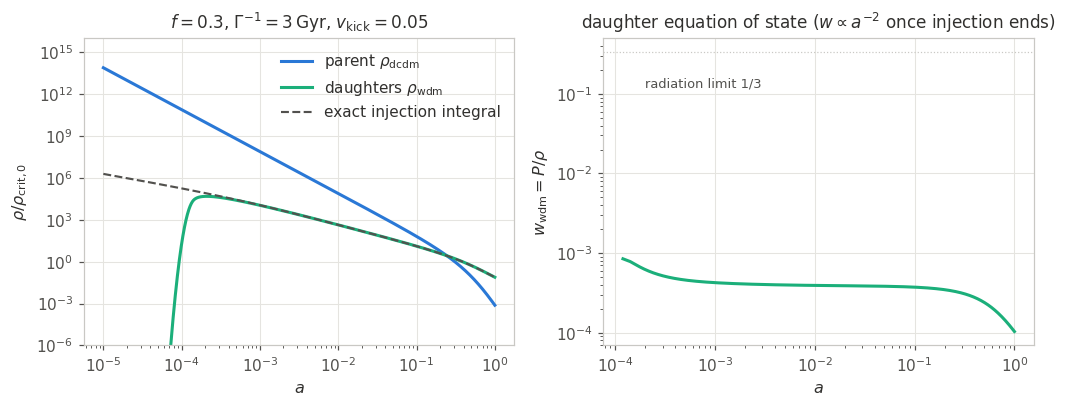

In [2]:
demo = run(ddm_pars(f=0.3, inv_gamma_gyr=3.0, vkick=0.05), background=True)
print(f"  {demo['t']:.1f} s")
bg = demo["bg"]
z = bgcol(bg, "z")
tau = bgcol(bg, "conf. time [Mpc]")
rho_dcdm = bgcol(bg, "rho_dcdm_ddm")
rho_wdm = bgcol(bg, "rho_wdm_ddm")
p_wdm = bgcol(bg, "p_wdm_ddm")
rho_crit0 = demo["H0"] ** 2
a = 1.0 / (1.0 + z)

# Exact injection-time integral (trapezoid over the background table)
v = 0.05
eps2 = 1.0 - v * v
Gamma_code = (GYR / 3.0) * 1e3 / 299792458.0  # km/s/Mpc -> Mpc^-1
integrand_fixed = a * Gamma_code * rho_dcdm  # a' * Gamma * rho_dcdm(a')
rho_exact = np.zeros_like(a)
for j in range(1, len(a)):
    x = a[: j + 1] / a[j]
    w = integrand_fixed[: j + 1] * x**3 * np.sqrt(eps2 + (1 - eps2) * x**2)
    rho_exact[j] = np.trapezoid(w, tau[: j + 1])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.6, 3.8))
sel = a > 1e-5
ax1.loglog(a[sel], rho_dcdm[sel] / rho_crit0, color=C1, label="parent $\\rho_{\\rm dcdm}$")
ax1.loglog(a[sel], rho_wdm[sel] / rho_crit0, color=C2, label="daughters $\\rho_{\\rm wdm}$")
good = sel & (rho_exact > 0)
ax1.loglog(a[good], rho_exact[good] / rho_crit0, "--", color=NEUTRAL, lw=1.4,
           label="exact injection integral")
ax1.set_ylim(1e-6, 1e16)  # hide the pre-grid seed-noise floor (~1e-10 rho_crit0)
ax1.set_xlabel("$a$"); ax1.set_ylabel("$\\rho / \\rho_{\\rm crit,0}$")
ax1.set_title("$f=0.3$, $\\Gamma^{-1}=3\\,$Gyr, $v_{\\rm kick}=0.05$")
ax1.legend()

w_eos = np.divide(p_wdm, rho_wdm, out=np.zeros_like(p_wdm), where=rho_wdm > 0)
sel2 = (a > 1.2e-4) & (w_eos > 0)  # post grid opening; seed noise below
ax2.loglog(a[sel2], w_eos[sel2], color=C2)
ax2.axhline(1.0 / 3.0, color="#c9c8c4", lw=0.8, ls=":")
ax2.text(2e-4, 0.12, "radiation limit 1/3", fontsize=8.5, color=NEUTRAL)
ax2.set_xlabel("$a$"); ax2.set_ylabel("$w_{\\rm wdm} = P/\\rho$")
ax2.set_title("daughter equation of state ($w \\propto a^{-2}$ once injection ends)")
fig.tight_layout()

# The ratio is only meaningful once the accumulated injection dominates the
# pre-grid decay tail: the grid opens at a = q_min_ratio = 1e-4, and the exact
# integral keeps the (deliberately dropped, ~1e-6 mass fraction) decays from
# before that, which swamp the ratio while the population is still tiny.
populated = good & (rho_wdm > 0) & (a >= 100 * 1e-4)
dev = np.max(np.abs(rho_exact[populated] / rho_wdm[populated] - 1))
print(f"max |rho_exact/rho_wdm - 1| for a >= 1e-2: {dev:.2e}")

The daughter distribution itself is stored in the background table (`f_ddm[i]` columns).
Analytically (paper Eq. 6, translated to code units) the stationary distribution behind the
moving cutoff is
$$\tilde f_0(q) \propto \frac{a_q^4\,\rho_{\rm dcdm}(a_q)}{q^4\,H(a_q)},\qquad a_q = q/q_{\rm kick},$$
each momentum remembering the decay rate at its injection epoch.

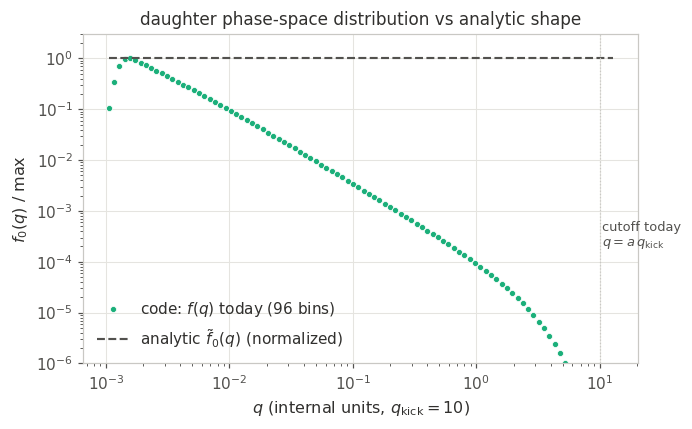

In [3]:
H_col = bgcol(bg, "H [1/Mpc]")
qkick = 10.0
fcols = sorted([k for k in bg.keys() if k.startswith("f_ddm[")],
               key=lambda s: int(s.split("[")[1][:-1]))
f_today = np.array([bg[k][-1] for k in fcols])
nbins = len(fcols)
# reconstruct the internal log-q grid (matches the C++ construction)
kernel_width, q_min_ratio = 1.0, 1e-4
du = np.log(1.0 / q_min_ratio) / (nbins - 3.0 * kernel_width)
u = np.log(qkick * q_min_ratio) + (np.arange(nbins) + 0.5) * du
q = np.exp(u)

a_q = q / qkick
rho_at = np.interp(a_q, a[::-1], rho_dcdm[::-1])
H_at = np.interp(a_q, a[::-1], H_col[::-1])
f_analytic = a_q**4 * rho_at / (q**4 * H_at)

plt.figure(figsize=(6.4, 4.0))
sel = f_today > 0
plt.loglog(q[sel], f_today[sel] / f_today[sel].max(), "o", ms=4, color=C2, mec="white",
           mew=0.5, label="code: $f(q)$ today (96 bins)")
plt.loglog(q, f_analytic / f_analytic[sel][f_today[sel].argmax()], "--", color=NEUTRAL,
           lw=1.4, label="analytic $\\tilde f_0(q)$ (normalized)")
plt.axvline(qkick, color="#c9c8c4", lw=0.8, ls=":")
plt.text(qkick * 1.05, 2e-4, "cutoff today\n$q=a\\,q_{\\rm kick}$", fontsize=8.5, color=NEUTRAL)
plt.xlabel("$q$ (internal units, $q_{\\rm kick}=10$)")
plt.ylabel("$f_0(q)$ / max")
plt.title("daughter phase-space distribution vs analytic shape")
plt.ylim(1e-6, 3)
plt.legend()
plt.tight_layout()

## 3. Limit checks

Three limits pin the implementation against known answers (run in full by
`scripts/validate_dcdm_wdm.py`; reproduced here visually):

1. **$v_{\rm kick}\to0$**: the daughters are born at rest — indistinguishable from stable CDM
   with the same total $\omega_m$.
2. **$v_{\rm kick}=1$** ($\varepsilon=0$): massless daughters — the model degenerates to the
   long-standing `dcdm_dr` implementation (cold DM → dark radiation).
3. **$f\to0$**: no unstable component — ΛCDM.

**A convention note for limit 2**: the two codes *classify* the massless daughters differently.
`dcdm_wdm` treats them as (warm) matter — they enter $P_m$ with their full $\delta\rho/\rho$,
per the standard CLASS convention for ncdm — while `dcdm_dr` treats them as dark radiation,
excluded from $P_m$. At $v_{\rm kick}=1$ this bookkeeping difference reaches 18% in $P_m$ even
though the dynamics agree ($C_\ell^{TT}$ to $5.5\times10^{-4}$). The convention-free comparison
is $P_{cb}$ (CDM+baryons), which excludes the daughters in both codes and agrees to
$3.1\times10^{-4}$. (Adding `dcdm_wdm` also required exposing $P_{cb}$ for composite-wrapped
warm species — the new `has_warm_matter()` collection property.)

runs: 3.2 s, 26.2 s, 1.4 s
max |dTT/TT| v->0: 2.5975370986364155e-06
max |dTT/TT| v=1 vs dr: 0.0005847766750033401
max |dPcb/Pcb| v=1 vs dr: 0.00032743277827829154


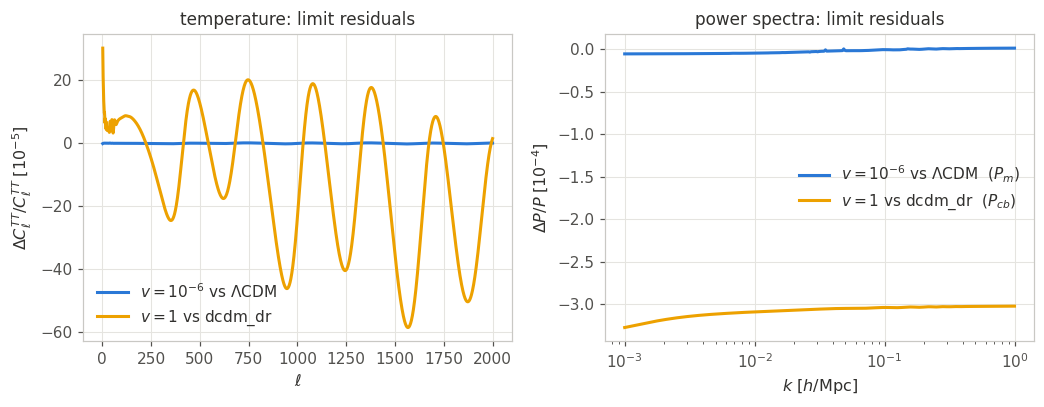

In [4]:
lim0 = run(ddm_pars(f=0.3, inv_gamma_gyr=GYR / 100.0, vkick=1e-6))
lim1 = run(ddm_pars(f=0.3, inv_gamma_gyr=GYR / 100.0, vkick=1.0))
dr = run({"Omega_cdm": OMEGA_DM * 0.7, "Omega_ini_dcdm": OMEGA_DM * 0.3,
          "Gamma_dcdm": 100.0})
print(f"runs: {lim0['t']:.1f} s, {lim1['t']:.1f} s, {dr['t']:.1f} s")

ll = np.arange(2, 2001)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9.6, 3.8))
ax1.plot(ll, 1e5 * (lim0["lensed"]["tt"][2:2001] / lcdm["lensed"]["tt"][2:2001] - 1),
         color=C1, label="$v=10^{-6}$ vs $\\Lambda$CDM")
ax1.plot(ll, 1e5 * (lim1["lensed"]["tt"][2:2001] / dr["lensed"]["tt"][2:2001] - 1),
         color=C3, label="$v=1$ vs dcdm_dr")
ax1.set_xlabel("$\\ell$"); ax1.set_ylabel("$\\Delta C_\\ell^{TT}/C_\\ell^{TT}\\;[10^{-5}]$")
ax1.set_title("temperature: limit residuals")
ax1.legend()

ax2.semilogx(lim0["k"], 1e4 * (lim0["pk"] / lcdm["pk"] - 1), color=C1,
             label="$v=10^{-6}$ vs $\\Lambda$CDM  ($P_m$)")
ax2.semilogx(lim1["k"], 1e4 * (lim1["pk_cb"] / dr["pk_cb"] - 1), color=C3,
             label="$v=1$ vs dcdm_dr  ($P_{cb}$)")
ax2.set_xlabel("$k$ [$h$/Mpc]"); ax2.set_ylabel("$\\Delta P/P\\;[10^{-4}]$")
ax2.set_title("power spectra: limit residuals")
ax2.legend()
fig.tight_layout()
print("max |dTT/TT| v->0:", np.max(np.abs(lim0['lensed']['tt'][2:2001]/lcdm['lensed']['tt'][2:2001]-1)))
print("max |dTT/TT| v=1 vs dr:", np.max(np.abs(lim1['lensed']['tt'][2:2001]/dr['lensed']['tt'][2:2001]-1)))
print("max |dPcb/Pcb| v=1 vs dr:", np.max(np.abs(lim1['pk_cb']/dr['pk_cb']-1)))

## 4. Recreating the physics panels of arXiv:2606.14849 (Fig. 3)

The paper's Fig. 3 shows fractional deviations from ΛCDM in $P(k)$, $C_\ell^{TT}$ and
$C_L^{\phi\phi}$ for $f=0.1$ and lifetimes $\Gamma^{-1} \in \{0.1, 1, 10\}$ Gyr, with
$\varepsilon$ chosen so that $v_{\rm kick}$ sits at their $1\sigma$ CMB upper limit. The
$1\sigma$ values are **read off their Fig. 2 (left panel, $f=0.1$ curve)** — approximately
$v/c \approx 0.03,\ 0.011,\ 0.02$ for $\Gamma^{-1} = 0.1,\ 1,\ 10$ Gyr (the bound is tightest
near $\Gamma^{-1}\sim1$ Gyr, where decays complete just as lensing becomes sensitive).

Expected physics (paper §IV.B): suppression of $P(k)$ onsets near the free-streaming scale
$k_{\rm fs} = 2\pi/\lambda_{\rm fs}$ (their Eq. 1, dashed vertical lines below); the
suppression propagates to $C_L^{\phi\phi}$ at the ~5–10% level over Planck's lensing range
$L\lesssim400$; the low-$\ell$ TT changes stay small. Earlier decays (shorter $\Gamma^{-1}$)
push $k_{\rm fs}$ to smaller scales and accumulate more growth suppression.

$$\lambda_{\rm fs} = \frac{v_{\rm kick}}{1+z_d}\int_0^{z_d}\frac{1+z}{H(z)}\,\mathrm{d}z,
\qquad H(z_d)=\Gamma,\qquad \ell_{\rm fs} \sim \pi\,\chi_*/\lambda_{\rm fs}.$$

Gamma^-1 =   0.1 Gyr, v = 0.03: 4.0 s
Gamma^-1 =   1.0 Gyr, v = 0.011: 3.8 s


Gamma^-1 =  10.0 Gyr, v = 0.02: 3.9 s
Gamma^-1=  0.1 Gyr: z_d=    39.6, k_fs=0.151 h/Mpc, l_fs=711
Gamma^-1=  1.0 Gyr: z_d=     7.8, k_fs=0.255 h/Mpc, l_fs=1201
Gamma^-1= 10.0 Gyr: z_d=     0.7, k_fs=0.240 h/Mpc, l_fs=1131


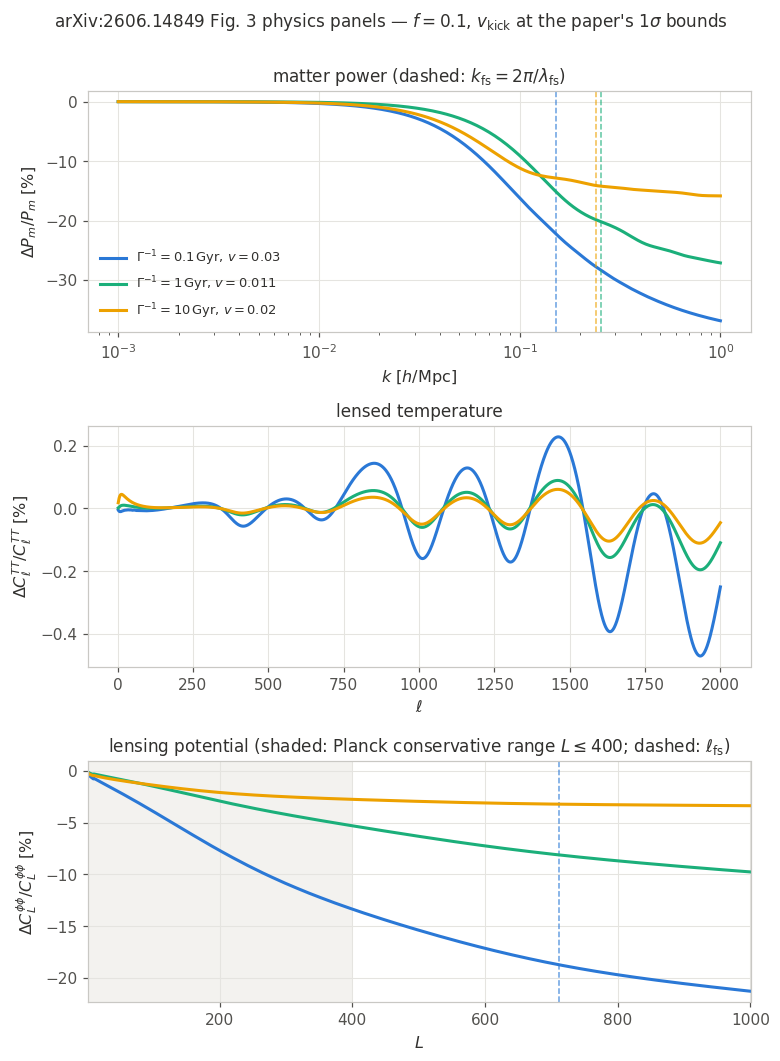

In [5]:
models = [(0.1, 0.03, C1), (1.0, 0.011, C2), (10.0, 0.02, C3)]
results = []
for inv_gamma, vk, color in models:
    r = run(ddm_pars(f=0.1, inv_gamma_gyr=inv_gamma, vkick=vk), background=True)
    results.append(r)
    print(f"Gamma^-1 = {inv_gamma:5.1f} Gyr, v = {vk}: {r['t']:.1f} s")


def freestream_scales(r, inv_gamma, vk):
    # z_d (H = Gamma), k_fs in h/Mpc, and l_fs ~ pi chi*/lambda_fs (paper Eq. 1)
    bgd = r["bg"]
    zb = bgcol(bgd, "z")
    Hb = bgcol(bgd, "H [1/Mpc]")
    Gamma_code = (GYR / inv_gamma) * 1e3 / 299792458.0
    z_d = zb[np.argmin(np.abs(Hb - Gamma_code))]
    sel = zb <= z_d
    zz, HH = zb[sel][::-1], Hb[sel][::-1]  # ascending z from 0 to z_d
    lam = vk / (1 + z_d) * np.trapezoid((1 + zz) / HH, zz)  # comoving Mpc
    chi_star = r["derived"]["ra_rec"]  # comoving Mpc
    k_fs = 2 * np.pi / lam / BASE["h"]  # h/Mpc
    return z_d, k_fs, np.pi * chi_star / lam


fig, axes = plt.subplots(3, 1, figsize=(7.2, 9.6), sharex=False)
LL = np.arange(2, 2001)
Lpp = np.arange(2, 1001)
for (inv_gamma, vk, color), r in zip(models, results):
    lab = f"$\\Gamma^{{-1}}={inv_gamma:g}\\,$Gyr, $v={vk}$"
    z_d, k_fs, l_fs = freestream_scales(r, inv_gamma, vk)
    print(f"Gamma^-1={inv_gamma:5.1f} Gyr: z_d={z_d:8.1f}, k_fs={k_fs:.3f} h/Mpc, l_fs={l_fs:.0f}")
    axes[0].semilogx(r["k"], 100 * (r["pk"] / lcdm["pk"] - 1), color=color, label=lab)
    if k_fs < 1.0:
        axes[0].axvline(k_fs, color=color, ls="--", lw=1.0, alpha=0.7)
    axes[1].plot(LL, 100 * (r["lensed"]["tt"][2:2001] / lcdm["lensed"]["tt"][2:2001] - 1),
                 color=color, label=lab)
    axes[2].plot(Lpp, 100 * (r["raw"]["pp"][2:1001] / lcdm["raw"]["pp"][2:1001] - 1),
                 color=color, label=lab)
    if l_fs < 1000:
        axes[2].axvline(l_fs, color=color, ls="--", lw=1.0, alpha=0.7)

axes[0].set_xlabel("$k$ [$h$/Mpc]")
axes[0].set_ylabel("$\\Delta P_m/P_m$ [%]")
axes[0].set_title("matter power (dashed: $k_{\\rm fs}=2\\pi/\\lambda_{\\rm fs}$)")
axes[0].legend(fontsize=8.5)
axes[1].set_xlabel("$\\ell$")
axes[1].set_ylabel("$\\Delta C_\\ell^{TT}/C_\\ell^{TT}$ [%]")
axes[1].set_title("lensed temperature")
axes[2].axvspan(2, 400, color="#f3f2ef", zorder=0)
axes[2].set_xlabel("$L$")
axes[2].set_ylabel("$\\Delta C_L^{\\phi\\phi}/C_L^{\\phi\\phi}$ [%]")
axes[2].set_title("lensing potential (shaded: Planck conservative range $L \\leq 400$; "
                  "dashed: $\\ell_{\\rm fs}$)")
axes[2].set_xlim(2, 1000)
fig.suptitle("arXiv:2606.14849 Fig. 3 physics panels — $f=0.1$, $v_{\\rm kick}$ at the "
             "paper's $1\\sigma$ bounds", y=1.0, fontsize=11)
fig.tight_layout()

The three panels reproduce the paper's qualitative anatomy: power suppression switching on
around $k_{\rm fs}$ and saturating at small scales; $C_L^{\phi\phi}$ suppressed at the several-percent
level across Planck's lensing range (the paper quotes 5–10% for $1\sigma$ models — the
constraining signal); and small low-$\ell$ TT shifts from the late-time background change.
Earlier decays (blue) push the suppression to higher $k$ and deepen it — the growth-suppression
accumulation the paper describes in §IV.B.

## 5. Momentum-grid convergence and cost

The only discretization knob is the momentum grid (log-spaced in $q$; the injection kernel is
resolved by construction — the grid spacing sets the kernel width). Halving/doubling the default
96 bins:

bins=  48:   1.7 s
bins=  96:   3.8 s
bins= 192:  10.7 s
max |P_48/P_192 - 1| = 2.05e-02
max |P_96/P_192 - 1| = 4.05e-03


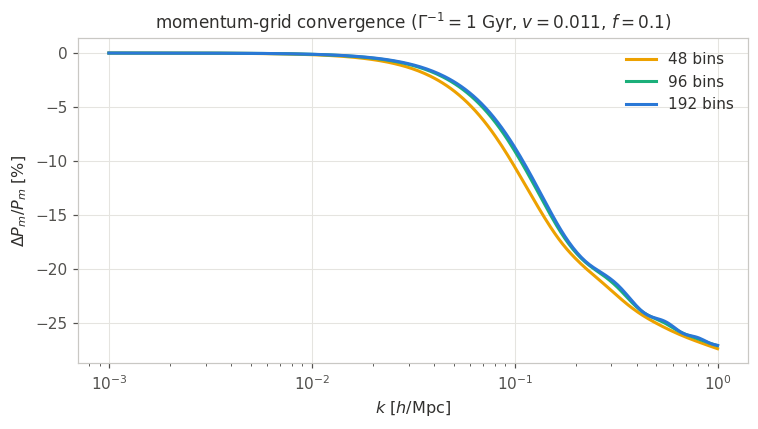

In [6]:
conv = {}
for bins in (48, 96, 192):
    r = run(ddm_pars(f=0.1, inv_gamma_gyr=1.0, vkick=0.011, bins=bins))
    conv[bins] = r
    print(f"bins={bins:4d}: {r['t']:5.1f} s")

plt.figure(figsize=(7.0, 4.0))
for bins, color in [(48, C3), (96, C2), (192, C1)]:
    plt.semilogx(conv[bins]["k"], 100 * (conv[bins]["pk"] / lcdm["pk"] - 1),
                 color=color, label=f"{bins} bins")
plt.xlabel("$k$ [$h$/Mpc]")
plt.ylabel("$\\Delta P_m/P_m$ [%]")
plt.title("momentum-grid convergence ($\\Gamma^{-1}=1$ Gyr, $v=0.011$, $f=0.1$)")
plt.legend()
plt.tight_layout()

d48 = np.max(np.abs(conv[48]["pk"] / conv[192]["pk"] - 1))
d96 = np.max(np.abs(conv[96]["pk"] / conv[192]["pk"] - 1))
print(f"max |P_48/P_192 - 1| = {d48:.2e}")
print(f"max |P_96/P_192 - 1| = {d96:.2e}")

**Cost summary** (Apple Silicon, single-threaded per run, `l_max_scalars = 2500`,
lensed spectra + $P(k)$):

| configuration | wall time |
|---|---|
| ΛCDM reference | ~2 s |
| `dcdm_wdm`, 96 bins, `evolver = 2` (RK45, recommended) | **~4 s** |
| `dcdm_wdm`, 96 bins, default `ndf15` | ~58 s |

`ndf15`'s implicit machinery (numerical Jacobians + LU on ~1700 equations per mode) is wasted
here — the daughter hierarchy is not stiff. `evolver = 2` agrees with `ndf15` to
$3.5\times10^{-5}$ on all observables.

## 6. Known limitations and follow-ups

- **Synchronous gauge only** (input guard rejects Newtonian). The $\ell=1$ injection source
  $\propto\theta_{\rm dcdm}$ is omitted — exact in synchronous gauge where $\theta_{\rm dcdm}\equiv0$.
- **No tensor contribution** from the daughters (their anisotropic stress is neglected for
  tensor modes; they are empty until late times).
- **No fluid approximation**: MCMC-grade speed would want an Abellán-style viscous-fluid mode
  for the daughters — a natural follow-up now that the exact reference exists (this notebook's
  runs at 4 s each are already MCMC-plausible with `evolver = 2`).
- **Very short lifetimes** ($\Gamma^{-1}$ short enough that decays complete before
  $a = $ `q_min_ratio` $=10^{-4}$) are outside the default grid window — lower `q_min_ratio`
  for such runs.
- **Unequal daughter masses** (paper footnote 1) are not implemented — the symmetric two-body
  case of the paper's main text is.
- `momenta_bins = 32` exactly (and only 32) trips a background failure under `-ffast-math`;
  under investigation, unrelated to physical results (use ≥ 48; the default is 96).
- The $P_m$ convention for relativistic daughters (counted as warm matter) differs from
  `dcdm_dr`'s dark-radiation classification — §3. For physical kick velocities
  ($v\lesssim0.1$) the daughters are non-relativistic at late times and $P_m$ is unambiguous.

**Numerical-robustness notes** (relevant to anyone extending the species; details in the
commit messages): the daughter's per-bin distribution values are seeded at $10^{-10}$ (the
stiff evolver's error weights choke on components starting at exact zero), the injection
kernel's exponential argument is clamped at 60 (extreme `exp` arguments are unsafe under
`-ffast-math`), and the injection switches on through a smooth Gaussian gate (a hard
switch-on stalls the BDF integrator).

## 7. The published Fig. 3, model by model

Section 4 recreated the figure's anatomy from three models guessed off the paper's Fig. 2;
this section runs the **exact nine models of the published figure**. The legend values
$(z_d,\ v_{\rm kick}/c)$ are

$$(133, 0.029),\ (80, 0.024),\ (48, 0.020),\ (28, 0.017),\ (17, 0.015),$$
$$(9.5, 0.015),\ (5.3, 0.017),\ (2.7, 0.024),\ (1.1, 0.048),$$

with $f=0.1$ and the Planck 2018 best-fit fiducial, including the 0.06 eV neutrino — declared
dot-style (`nu.type = ncdm_standard`, `nu.m = 0.06`) because the legacy `N_ncdm` key collides
with dot-instance parsing when a `ddm.*` instance is present. The decay rate follows from the
paper's definition $\Gamma = H(z_d)$; on this background the nine $z_d$ values map onto an
almost exactly $10^{1/3}$-spaced lifetime grid $\Gamma^{-1} = 0.0164 \to 7.64$ Gyr — strong
evidence this is the mapping the authors used.

Two conventions were pinned down by pixel-measuring the published PNG
(`arXiv-2606.14849v1/DESIDDM/cmb_3panel.png`):

- The **dashed free-streaming markers** use $\lambda_{\rm fs} = 2\times$ [Eq. (1) integral].
  (The paper's Eq. (1) as printed and its quoted matter-domination limit
  $\lambda_{\rm fs}\approx 22{,}000\,(v/c)/\sqrt{1+z_d}\ h^{-1}$Mpc differ by exactly a factor
  of 2; the figure follows the latter.) The $P(k)$ panel marks $k_{\rm fs}=2\pi/\lambda_{\rm fs}$
  and **both** $C_\ell$ panels mark $\ell_{\rm fs}=\pi\chi_*/\lambda_{\rm fs}$; the measured
  line positions match these to $\sim$10%, consistent with the legend's 2-significant-figure
  rounding.
- The TT panel is **log-$x$** with $\ell \in (2, 3000)$; the $\phi\phi$ panel spans
  $L \in (10, 800)$; the $y$-ranges are autoscaled.

The figure is produced by the standalone script `dcdm_wdm_fig3_9models.py` next to this
notebook (spectra cached in `dcdm_wdm_fig3_cache.npz`; delete the cache to force a recompute —
about a minute with `evolver = 2`).

loaded cached spectra from /Users/au192734/Projects/class_claude/notebooks/dcdm_wdm_fig3_cache.npz
z_d =   133: Gamma^-1 =  0.0164 Gyr, k_fs = 0.0883 1/Mpc, l_fs = 612
z_d =    80: Gamma^-1 =  0.0351 Gyr, k_fs = 0.0854 1/Mpc, l_fs = 592
z_d =    48: Gamma^-1 =  0.0749 Gyr, k_fs = 0.0830 1/Mpc, l_fs = 576
z_d =    28: Gamma^-1 =  0.1649 Gyr, k_fs = 0.0797 1/Mpc, l_fs = 553
z_d =    17: Gamma^-1 =  0.3377 Gyr, k_fs = 0.0767 1/Mpc, l_fs = 532
z_d =   9.5: Gamma^-1 =  0.7582 Gyr, k_fs = 0.0660 1/Mpc, l_fs = 458
z_d =   5.3: Gamma^-1 =  1.6268 Gyr, k_fs = 0.0535 1/Mpc, l_fs = 371
z_d =   2.7: Gamma^-1 =  3.5558 Gyr, k_fs = 0.0385 1/Mpc, l_fs = 267
z_d =   1.1: Gamma^-1 =  7.6450 Gyr, k_fs = 0.0253 1/Mpc, l_fs = 176


wrote /Users/au192734/Projects/class_claude/notebooks/dcdm_wdm_fig3_9models.png


wrote /Users/au192734/Projects/class_claude/notebooks/dcdm_wdm_fig3_9models.pdf


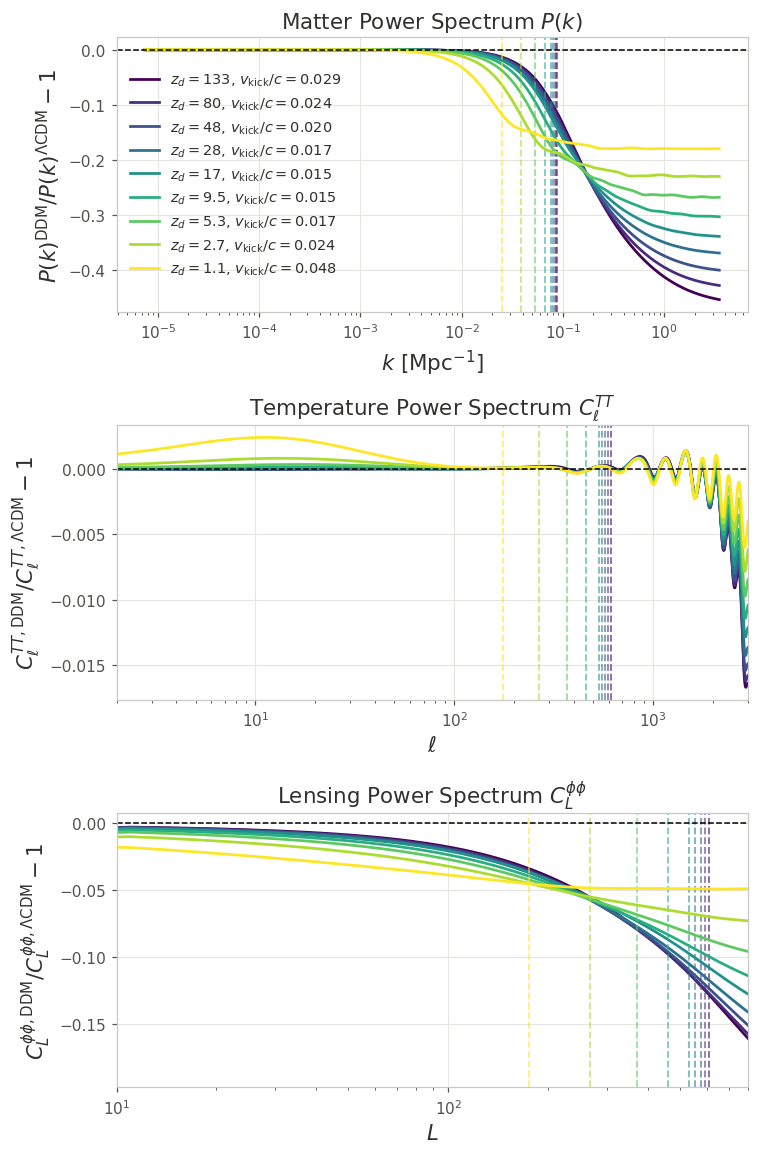

In [7]:
import runpy

# Executes the standalone generator (uses the .npz cache when present; ~1 min otherwise).
fig3 = runpy.run_path("dcdm_wdm_fig3_9models.py", run_name="notebook")

### Agreement — and one genuine discrepancy

Panel by panel against the published figure:

- **$P(k)$: matches curve-for-curve** — plateau depths from $-0.18$ ($z_d=1.1$) to $-0.46$
  ($z_d=133$), common crossing at $k\approx0.15\,\mathrm{Mpc}^{-1}$, onset at the $k_{\rm fs}$
  markers.
- **$C_L^{\phi\phi}$: matches** — crossing at $L\approx250$, earliest decay reaching $-0.16$.
- **$C_\ell^{TT}$, $\ell\gtrsim50$: matches**, including the lensing-smoothing oscillations
  growing to $-1.7\%$ at $\ell=3000$.
- **$C_\ell^{TT}$, $\ell\lesssim50$: disagrees for the early decayers.** The published panel
  shows $+0.8\%/{+1.1\%}$ at $\ell=2$ for $z_d=133/80$ — with *non-monotonic* ordering (80
  above 133, 28 above 48) — while we find $\lesssim10^{-4}$ there. The late decayers agree:
  our $z_d=1.1$ model reproduces the published yellow $+0.2\%$ bump at $\ell\approx10$–$15$.

Four quantitative arguments that the published low-$\ell$ excess is an artifact of
`CLASSIER-DDM`'s background solution rather than physics missing here:

1. **Energy conservation.** Two daughters of total mass $\varepsilon m_\chi$ shed only the
   kinetic fraction: the asymptotic mass loss is $f\,(1-\varepsilon)\approx f\,v_{\rm kick}^2/2
   \approx 4\times10^{-5}$ of the DM for the most extreme model ($z_d=133$, $v=0.029$). Our
   background confirms $\Delta\rho_m/\rho_m = 5$–$9\times10^{-5}$ (including mid-decay
   transients). Calibration runs give a low-$\ell$ response $\Delta C_2/C_2 \approx
   0.5\,(\Delta\Omega_m/\Omega_m)$ for a deficit established early (constant at late times, as
   for $z_d\gtrsim80$): the published $+0.8$–$1.1\%$ would need $\Delta\Omega_m/\Omega_m\sim2\%$
   — i.e. the sector losing $\sim$20% of its energy, $v_{\rm eff}\sim0.6$ instead of $0.029$.
2. **The paper's own numbers.** §V states the bounds limit the mass loss to
   $\Delta\Omega_m/\Omega_m \lesssim 0.1\%$ — itself $\sim$20× larger than energy conservation
   gives at these $(f, v)$, yet still capping the $\ell=2$ response at $\sim+0.05\%$, an order
   of magnitude below their own panel.
3. **The known strong-late-ISW benchmark.** `dcdm_dr` at the same $\Gamma^{-1}=7.6\,$Gyr,
   $f=0.1$ gives $+9.7\%$ at $\ell=2$ — the familiar large DCDM$\to$DR signal — because there
   the sector loses its *entire* rest energy. Two massive daughters suppress exactly this by
   $(1-\varepsilon)\approx v_{\rm kick}^2/2$, and deficits developing *during* the $\Lambda$ era
   are $\sim$30× more ISW-efficient per unit deficit than early-established ones — which is why
   only the late decayers show a visible (and mutually agreeing) low-$\ell$ signal.
4. **Closure-condition conventions cannot bridge the gap.** The paper's basis fixes
   $\omega_\Lambda$ (h derived); a CLASS-style closure fixes $h$ ($\Omega_\Lambda$ derived).
   Explicit runs in both conventions at the true deficit move $C_2$ by $+3\times10^{-5}$ and
   $-1\times10^{-5}$ respectively. Incidentally, our runs effectively sit in the *paper's*
   convention: the composite's fixed-point shoot of the $\Omega_{\rm dcdmwdm}$ closure reserve
   only engages when its residual exceeds `fzero_Newton`'s tolF $=10^{-3}$ (it does for
   $v\gtrsim0.3$; verified re-closing exactly at $v=0.5$ and $v=1$). At physical kicks
   $\rho_\Lambda$ keeps the `Omega_ini` seed and the realized $H_0$ absorbs
   $-\delta_{\rm kin}/2\approx-1.4\times10^{-5}$ — cosmologically negligible, but worth knowing.
   (Related: the $v=1$ validation floor of $5.5\times10^{-4}$ in §3 is partly `dcdm_dr`'s own
   shooting tolerance — its $v=1$ run realizes $H_0$ off by $-3.6\times10^{-4}$ while the
   composite converges to $10^{-9}$.)

**Bottom line**: the perturbation physics of `dcdm_wdm` reproduces the published figure
quantitatively; the residual low-$\ell$ TT disagreement for early decays is internally
inconsistent within the paper itself and is being raised with the authors.